In [121]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [122]:
df = pd.read_csv("hapur_house_price_dataset.csv")

In [123]:
df.head(10)

,location,gaj,bhk,bath,balcony,age,floor,total_floor,property_type,furnishing,price
0,Gandhi Ganj,152,4,1,2,10,4,5,Villa,Furnished,5055168
1,Vijay Nagar,152,2,1,2,10,2,3,Builder Floor,Unfurnished,4667176
2,Pilkhuwa Road,201,3,2,0,1,3,5,Villa,Furnished,5059033
3,Kothi Gate,241,4,1,0,11,1,3,Villa,Furnished,6611436
4,Gandhi Ganj,285,1,1,0,9,3,5,Builder Floor,Furnished,5503865
5,Gandhi Ganj,224,3,3,3,2,4,5,Villa,Unfurnished,5851360
6,Laxmi Nagar,184,5,1,2,17,3,4,Independent House,Furnished,5772120
7,Arya Nagar,63,2,2,0,1,3,5,Builder Floor,Furnished,2604581
8,Meerut Road,313,3,2,0,3,1,5,Independent House,Unfurnished,12800041
9,Shastri Nagar,103,2,2,1,17,1,5,Builder Floor,Unfurnished,1626583


In [124]:
dfAfterEDA = df

<Axes: >

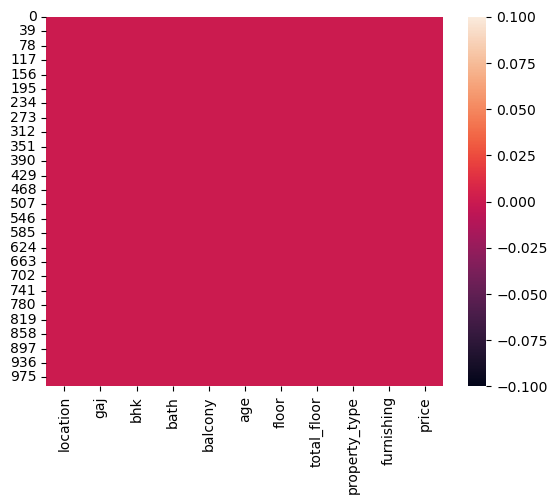

In [125]:
sns.heatmap(dfAfterEDA.isnull())

In [126]:
OneHot = OneHotEncoder(drop = None, sparse_output = False)

In [127]:
dfAfterEDA["furnishing"].unique()

array(['Furnished', 'Unfurnished', 'Semi-Furnished'], dtype=object)

In [128]:
furnishingOneHotEncoded = OneHot.fit_transform(dfAfterEDA[["furnishing"]])
furnishingOneHotEncodedDf = pd.DataFrame(furnishingOneHotEncoded, columns = OneHot.get_feature_names_out(["furnishing"]), index = dfAfterEDA.index)
dfAfterEDA = pd.concat([dfAfterEDA, furnishingOneHotEncodedDf], axis = 1)
dfAfterEDA = dfAfterEDA.drop(columns = ["furnishing"])
dfAfterEDA.head(5)

,location,gaj,bhk,bath,balcony,age,floor,total_floor,property_type,price,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished
0,Gandhi Ganj,152,4,1,2,10,4,5,Villa,5055168,1.0,0.0,0.0
1,Vijay Nagar,152,2,1,2,10,2,3,Builder Floor,4667176,0.0,0.0,1.0
2,Pilkhuwa Road,201,3,2,0,1,3,5,Villa,5059033,1.0,0.0,0.0
3,Kothi Gate,241,4,1,0,11,1,3,Villa,6611436,1.0,0.0,0.0
4,Gandhi Ganj,285,1,1,0,9,3,5,Builder Floor,5503865,1.0,0.0,0.0


In [129]:
dfAfterEDA["property_type"].unique()

array(['Villa', 'Builder Floor', 'Independent House', 'Plot'],
      dtype=object)

In [130]:
property_typeOneHotEncoded = OneHot.fit_transform(dfAfterEDA[["property_type"]])
property_typeOneHotEncodedDf = pd.DataFrame(property_typeOneHotEncoded, columns = OneHot.get_feature_names_out(["property_type"]), index = dfAfterEDA.index)
dfAfterEDA = pd.concat([dfAfterEDA, property_typeOneHotEncodedDf], axis = 1)
dfAfterEDA = dfAfterEDA.drop(columns = ["property_type"])
dfAfterEDA.head(5)

,location,gaj,bhk,bath,balcony,age,floor,total_floor,price,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,property_type_Builder Floor,property_type_Independent House,property_type_Plot,property_type_Villa
0,Gandhi Ganj,152,4,1,2,10,4,5,5055168,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Vijay Nagar,152,2,1,2,10,2,3,4667176,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,Pilkhuwa Road,201,3,2,0,1,3,5,5059033,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Kothi Gate,241,4,1,0,11,1,3,6611436,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Gandhi Ganj,285,1,1,0,9,3,5,5503865,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [131]:
loc = dfAfterEDA["location"].value_counts()
loc

location
Meerut Road             80
Shastri Nagar           74
Simbhaoli Road          72
Arya Nagar              70
Hapur Bypass            66
Railway Road            64
Laxmi Nagar             62
Delhi Road              62
Kavi Nagar Extension    62
Pilkhuwa Road           60
Garh Road               60
Gandhi Ganj             58
Babugarh Road           57
Freeganj Road           56
Vijay Nagar             55
Kothi Gate              42
Name: count, dtype: int64

In [132]:
targetEncoderForLocation = dfAfterEDA.groupby("location")["price"].mean()
targetEncoderForLocation

location
Arya Nagar              7.084777e+06
Babugarh Road           6.197725e+06
Delhi Road              6.667002e+06
Freeganj Road           7.560478e+06
Gandhi Ganj             6.994141e+06
Garh Road               6.298186e+06
Hapur Bypass            7.314225e+06
Kavi Nagar Extension    6.064263e+06
Kothi Gate              6.671490e+06
Laxmi Nagar             6.486157e+06
Meerut Road             6.755416e+06
Pilkhuwa Road           7.357652e+06
Railway Road            6.709367e+06
Shastri Nagar           6.883263e+06
Simbhaoli Road          5.861220e+06
Vijay Nagar             6.556568e+06
Name: price, dtype: float64

In [133]:
dfAfterEDA["location"] = dfAfterEDA["location"].map(targetEncoderForLocation)

In [134]:
dfAfterEDA.head(20)

,location,gaj,bhk,bath,balcony,age,floor,total_floor,price,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,property_type_Builder Floor,property_type_Independent House,property_type_Plot,property_type_Villa
0,6.994141e+06,152,4,1,2,10,4,5,5055168,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.556568e+06,152,2,1,2,10,2,3,4667176,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,7.357652e+06,201,3,2,0,1,3,5,5059033,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,6.671490e+06,241,4,1,0,11,1,3,6611436,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6.994141e+06,285,1,1,0,9,3,5,5503865,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,6.994141e+06,224,3,3,3,2,4,5,5851360,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6,6.486157e+06,184,5,1,2,17,3,4,5772120,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,7.084777e+06,63,2,2,0,1,3,5,2604581,1.0,0.0,0.0,1.0,0.0,0.0,0.0
8,6.755416e+06,313,3,2,0,3,1,5,12800041,0.0,0.0,1.0,0.0,1.0,0.0,0.0
9,6.883263e+06,103,2,2,1,17,1,5,1626583,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [135]:
x = dfAfterEDA.drop(columns = ["price"])
y = dfAfterEDA["price"]

In [136]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .2, random_state = 12)

In [137]:
linearRegression = LinearRegression()

In [138]:
model = linearRegression.fit(x_train, y_train)

In [139]:
y_pred = linearRegression.predict(x_test)

In [140]:
y_test.iloc[0]

8761120

In [141]:
linearRegression.score(x_test, y_test)

0.7780179841796255

In [142]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1111430.2445617926
MSE: 2016673211176.2993
RMSE: 1420096.1978599546
R2: 0.7780179841796255


In [160]:
new_data = pd.DataFrame([{
    "location": 6.994141e+06,
    "gaj": 152,
    "bhk": 4,
    "bath": 1,
    "balcony": 2, 
    "age": 10, 
    "floor": 4,
    "total_floor": 5,
    "furnishing_Furnished":	1,
    "furnishing_Semi-Furnished": 0,
    "furnishing_Unfurnished": 0,
    "property_type_Builder Floor": 0,
    "property_type_Independent House": 0,
    "property_type_Plot": 0,
    "property_type_Villa": 1
}])
pred = model.predict(new_data)
print(pred)

[4741375.78647137]
